# SCALib TVLA with ChipWhisperer (실물 AES)

## 학습 목표

이 노트북은 **실물 ChipWhisperer**로 AES-128 전력 파형을 모은 뒤, **SCALib `Ttest`**로 TVLA(누설 진단)를 수행한다.

| 구성 | 역할 |
|------|------|
| **ChipWhisperer-Lite** | 타겟과 SimpleSerial2 통신, 펌웨어 플래시, 시스템 클럭(HS2) 공급 |
| **ChipWhisperer-Husky** | 트리거·클럭·션트를 와이어태핑으로 측정 (통신에는 개입하지 않음) |
| **CW308 + STM32F3** | 타겟 MCU |
| **tiny-AES-c** | 타겟 펌웨어의 AES-128 ECB |
| **SCALib** | `scalib.metrics.Ttest` (pip 패키지) |

시뮬 전용 입문 노트북 `SCALib_TVLA_tutorial.ipynb`와 **같은 TVLA API**를 쓴다.  
차이는 파형 출처가 시뮬이 아니라 **실측**이라는 점이다.

### 진행 순서

| 단계 | 내용 |
|:----:|------|
| 1 | SCALib 설치 |
| 2 | 헬퍼·상수 정의 |
| 3 | Lite + Husky 연결, 타겟 오픈 |
| 4 | AES 펌웨어 빌드·플래시 |
| 5 | 골든 모델로 AES 통신 검증 |
| 6 | Husky 와이어태핑 측정 설정 |
| 7 | fixed-key vs random-key 파형 수집 |
| 8 | float→int16 변환 후 SCALib TVLA |
| 9 | 자원 해제 |

### 배선 전제 (와이어태핑)

```text
호스트 PC
  ├─ USB ─ ChipWhisperer-Lite  ──20pin── CW308 (UART, HS2 클럭, 프로그래밍)
  └─ USB ─ ChipWhisperer-Husky
              ├─ USERIO D0  ←  CW308 TRIG (GPIO4)
              ├─ AUX MCX    ←  CW308 CLKIN (클럭 분기)
              └─ Measure    ←  CW308 SHUNTL
```

Lite와 Husky가 모두 USB에 보이도록 연결한 뒤 셀을 실행한다.


---
## 1. SCALib 설치

chipwhisperer-kor 기본 이미지는 Python 3.9이다.  
SCALib 0.6.1 이상은 Python 3.10을 요구하므로, 여기서는 **`scalib>=0.6.0,<0.6.1`**로 설치한다.


In [1]:
%pip install -q "scalib>=0.6.0,<0.6.1"


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import time
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import chipwhisperer as cw
from Crypto.Cipher import AES

import scalib
from scalib.metrics import Ttest

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

print("Python :", sys.version.split()[0])
print("SCALib :", scalib.__version__)
print("위치   :", scalib.__file__)


Python : 3.9.25
SCALib : 0.6.0
위치   : /usr/local/lib/python3.9/site-packages/scalib/__init__.py


---
## 2. 헬퍼와 실험 상수

`my_fsr_cmd`는 SimpleSerial2 명령 한 번을 보내고 응답을 읽는다.  
AES 블록 길이는 **16바이트**이다.


In [3]:
def my_fsr_cmd(target, cmd, scmd, data, payload_only=False):
    # SimpleSerial2 명령 전송·응답 수신
    # cmd: 0x81 init, 0x82 update, 0x83 final
    # scmd: 'k','p','l','c','r'
    target.flush()
    target.send_cmd(cmd=cmd, scmd=ord(scmd), data=data)
    response = target.read_cmd(timeout=500)
    if response is None:
        return None
    if payload_only:
        return response[3 : 3 + response[2]]
    return response


def aes_ecb_encrypt(key16, plain16):
    # 호스트 골든 모델: AES-128 ECB 한 블록
    return AES.new(bytes(key16), AES.MODE_ECB).encrypt(bytes(plain16))


PLATFORM = "CW308_STM32F3"
CRYPTO_TARGET = "NONE"  # base 내장 crypto 미사용, tiny-AES-c 직접 링크
SS_VER = "SS_VER_2_1"
AES_BLOCK = 16

NB_DIR = Path.cwd()
SS_DIR = NB_DIR / "simpleserial_main"
HEX_PATH = SS_DIR / ("simpleserial-base-%s.hex" % PLATFORM)

N_TRACES = 200  # 집단당 트레이스 수. 늘리면 |t| 통계가 안정된다.
TVLA_SEED = 42
THRESHOLD = 4.5  # 관례 경보선

print("SS_DIR  :", SS_DIR)
print("HEX_PATH:", HEX_PATH)
print("N_TRACES:", N_TRACES)


SS_DIR  : /workspace/[extra] TVLA/simpleserial_main
HEX_PATH: /workspace/[extra] TVLA/simpleserial_main/simpleserial-base-CW308_STM32F3.hex
N_TRACES: 200


---
## 3. Lite + Husky 연결

USB에 연결된 모든 ChipWhisperer를 열고, 이름 규칙으로 Lite와 Husky를 고른다.  
장치가 없거나 이름 키가 다르면 예외가 난다. `cw.list_devices()` 출력을 확인한다.


In [4]:
def connect_all_devices():
    # 연결된 ChipWhisperer를 모두 열어 {이름: scope} 딕셔너리를 반환한다.
    device_list = cw.list_devices()
    if not device_list:
        raise RuntimeError("연결된 ChipWhisperer 장치가 없다. USB 연결을 확인한다.")

    print("발견된 장치 수:", len(device_list))
    scopes = {}
    for device in device_list:
        name = device["name"].replace("-", "_")
        sn = device["sn"]
        try:
            scopes[name] = cw.scope(sn=sn)
            print("  [OK]", name, " (SN:", sn, ")")
        except Exception as e:
            print("  [FAIL]", name, " (SN:", sn, ") ", e)
    return scopes


scopes = connect_all_devices()

lite_scope = scopes["ChipWhisperer_Lite"]
husky_scope = scopes["ChipWhisperer_Husky"]

if SS_VER != "SS_VER_2_1":
    raise OSError("이 노트북은 SS_VER_2_1 만 지원한다.")

target = cw.target(lite_scope, cw.targets.SimpleSerial2)
print("[OK] Lite에 SimpleSerial2 타겟 연결")


발견된 장치 수: 2
  [OK] ChipWhisperer_Husky  (SN: 502032204c5846303130313137313032 )
  [OK] ChipWhisperer_Lite  (SN: 44203120394d36433130322030313035 )
[OK] Lite에 SimpleSerial2 타겟 연결


---
## 4. 펌웨어 빌드와 플래시

`simpleserial_main`은 **tiny-AES-c**의 AES-128 ECB를 `MY_AES_ECB`로 호출한다.  
`CRYPTO_TARGET=NONE`이므로 base 쪽 AES 라이브러리가 아니라 로컬 `aes.c`가 링크된다.

빌드 산출물: `simpleserial_main/simpleserial-base-CW308_STM32F3.hex`  
플래시는 **Lite**가 프로그래머 역할을 한다.


In [5]:
def build_firmware():
    if not SS_DIR.is_dir():
        raise FileNotFoundError("펌웨어 폴더가 없다: %s" % SS_DIR)

    cmd = [
        "make",
        "PLATFORM=%s" % PLATFORM,
        "CRYPTO_TARGET=%s" % CRYPTO_TARGET,
        "SS_VER=%s" % SS_VER,
    ]
    print("빌드:", " ".join(cmd), "cwd=", SS_DIR)
    r = subprocess.run(cmd, cwd=str(SS_DIR), capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout)
        print(r.stderr)
        raise RuntimeError("펌웨어 빌드 실패")
    if not HEX_PATH.is_file():
        raise FileNotFoundError("hex 없음: %s" % HEX_PATH)
    print("[OK] 빌드 완료:", HEX_PATH)


def flash_firmware():
    if "STM" not in PLATFORM and PLATFORM not in ("CWLITEARM", "CWNANO"):
        raise OSError("지원하지 않는 PLATFORM: %s" % PLATFORM)
    prog = cw.programmers.STM32FProgrammer
    lite_scope.default_setup()
    cw.program_target(lite_scope, prog, str(HEX_PATH))
    print("[OK] 플래시 완료")


build_firmware()
flash_firmware()


빌드: make PLATFORM=CW308_STM32F3 CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1 cwd= /workspace/[extra] TVLA/simpleserial_main
[OK] 빌드 완료: /workspace/[extra] TVLA/simpleserial_main/simpleserial-base-CW308_STM32F3.hex
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 188149131                 to 199967823                
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq           

---
## 5. AES 골든 모델 검증

고정 키·평문 16바이트를 타겟에 보내고, 암호문이 호스트 `AES-ECB` 결과와 같은지 확인한다.  
불일치하면 플래시·배선·`len` 설정을 점검한다. 이 셀이 통과해야 이후 수집이 의미 있다.


In [6]:
def target_aes_encrypt(key16, plain16):
    # 타겟 AES-128 ECB 한 블록
    # 0x81 k/p/l → 0x82 c → 0x83 r
    key16 = bytearray(key16)
    plain16 = bytearray(plain16)
    if len(key16) != AES_BLOCK or len(plain16) != AES_BLOCK:
        raise ValueError("key/plain 길이는 16이어야 한다.")

    my_fsr_cmd(target, 0x81, "k", key16)
    my_fsr_cmd(target, 0x81, "p", plain16)
    my_fsr_cmd(target, 0x81, "l", bytearray([AES_BLOCK]))
    my_fsr_cmd(target, 0x82, "c", [])
    ct = my_fsr_cmd(target, 0x83, "r", [], payload_only=True)
    if ct is None:
        raise RuntimeError("타겟 응답 없음 (통신 실패)")
    return bytes(ct)


random.seed(0)
k_test = bytearray(random.randint(0, 255) for _ in range(AES_BLOCK))
p_test = bytearray(random.randint(0, 255) for _ in range(AES_BLOCK))
ct_hw = target_aes_encrypt(k_test, p_test)
ct_sw = aes_ecb_encrypt(k_test, p_test)

print("key :", k_test.hex(" "))
print("pt  :", p_test.hex(" "))
print("HW  :", ct_hw.hex(" "))
print("SW  :", ct_sw.hex(" "))
if ct_hw == ct_sw:
    print("[OK] 골든 모델 일치 — AES 통신·연산 정상")
else:
    raise RuntimeError("골든 모델 불일치 — 플래시·배선·펌웨어를 확인한다.")


key : c5 d7 14 84 f8 cf 9b f4 b7 6f 47 90 47 30 80 4b
pt  : 9e 32 25 a9 f1 33 b5 de a1 68 f4 e2 85 1f 07 2f
HW  : 82 88 0a bc c8 46 0c e3 26 0b 26 69 60 21 6f 08
SW  : 82 88 0a bc c8 46 0c e3 26 0b 26 69 60 21 6f 08
[OK] 골든 모델 일치 — AES 통신·연산 정상


---
## 6. Husky 와이어태핑 측정 설정

Husky는 타겟 통신에 끼어들지 않고, **외부 클럭·TRIG·션트**만 본다.

1. AUX를 high-Z 입력으로 두고 PLL 소스를 `extclk_aux_io`로 둔다.
2. 주파수 카운터로 외부 클럭을 추정한 뒤 `clkgen_freq`에 맞추고 `adc_mul=4`로 오버샘플한다.
3. 트리거는 전면 USERIO D0, 상승 엣지.
4. 게인·샘플 수는 환경에 맞게 조절한다 (클리핑이 있으면 gain을 낮춘다).


In [7]:
husky_scope.default_setup()
time.sleep(0.5)

# [1] 외부 클럭 입력
husky_scope.clock.clkgen_freq = 0
husky_scope.clock.reset_adc()
husky_scope.io.aux_io_mcx = "high_z"
husky_scope.clock.clkgen_src = "extclk_aux_io"
husky_scope.clock.reset_adc()
print("aux_io_mcx   =", husky_scope.io.aux_io_mcx)
print("clkgen_src   =", husky_scope.clock.clkgen_src)

# [2] 주파수 추정 및 PLL
husky_scope.clock.pll._allow_rdiv = True
husky_scope.clock.freq_ctr_src = "extclk"
time.sleep(0.5)

freqs = []
for _ in range(20):
    freqs.append(husky_scope.clock.freq_ctr)
    time.sleep(0.2)
freq_series = pd.Series(freqs)
clk_hz = float(freq_series.mode().iloc[0])
print("외부 클럭 최빈값 ≈ %.0f Hz" % clk_hz)

husky_scope.clock.clkgen_freq = clk_hz
husky_scope.clock.adc_mul = 4
husky_scope.clock.reset_adc()
print("adc_locked   =", husky_scope.clock.adc_locked, " adc_freq =", husky_scope.clock.adc_freq)
print("clkgen_locked=", husky_scope.clock.clkgen_locked, " clkgen_freq =", husky_scope.clock.clkgen_freq)

if not husky_scope.clock.adc_locked or not husky_scope.clock.clkgen_locked:
    raise RuntimeError("Husky PLL/ADC lock 실패 — AUX 클럭 배선과 진폭을 확인한다.")

# [3] 트리거
husky_scope.trigger.triggers = "userio_d0"
husky_scope.trigger.module = "basic"
husky_scope.adc.basic_mode = "rising_edge"

# [4] ADC 파라미터
husky_scope.gain.db = 25
husky_scope.adc.samples = 10000
husky_scope.adc.offset = 0
husky_scope.adc.presamples = 0

print("gain.db      =", husky_scope.gain.db)
print("adc.samples  =", husky_scope.adc.samples)
print("[OK] Husky 측정 설정 완료")


scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen                   
scope.glitch.phase_shift_steps           changed from 0                         to 4592                     
scope.trace.capture

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


외부 클럭 최빈값 ≈ 7384494 Hz


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


adc_locked   = True  adc_freq = 29537976.0
clkgen_locked= True  clkgen_freq = 7384494.0
gain.db      = 25.091743119266056
adc.samples  = 10000
[OK] Husky 측정 설정 완료


---
## 7. TVLA용 파형 수집

### 시나리오 (시뮬 튜토리얼과 동일)

| 집단 | 키 | 평문 | 라벨 |
|------|----|------|------|
| 0 | 트레이스마다 **랜덤** | **고정** | 0 |
| 1 | **고정 키** | **동일 고정 평문** | 1 |

비보호 AES라면 집단 간 평균 전력 차이가 남아 **1차 |t|가 커지는 구간**이 나타나기 쉽다.  
수집 대상 파형은 **Husky**만 사용한다.

`N_TRACES`를 키우면 시간이 늘지만 t 통계가 안정된다.


고정 평문: [102 220 225  95 179  61 234 203  92   3  98 243  14 149 245  46]
고정 키  : [106 244  99 187  71 212 153 199 188 174  65 153  20  44 203 152]

=== 집단 0: random-key, N=200 ===
  random-key: 20/200
  random-key: 40/200
  random-key: 60/200
  random-key: 80/200
  random-key: 100/200
  random-key: 120/200
  random-key: 140/200
  random-key: 160/200
  random-key: 180/200
  random-key: 200/200

=== 집단 1: fixed-key, N=200 ===
  fixed-key: 20/200
  fixed-key: 40/200
  fixed-key: 60/200
  fixed-key: 80/200
  fixed-key: 100/200
  fixed-key: 120/200
  fixed-key: 140/200
  fixed-key: 160/200
  fixed-key: 180/200
  fixed-key: 200/200

traces_rk (200, 10000) float64
traces_fk (200, 10000) float64


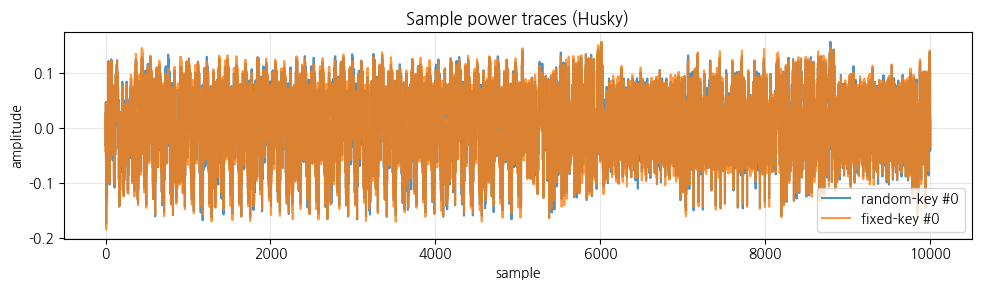

In [8]:
def capture_one(key16, plain16):
    # Husky arm → 타겟 AES → capture → (wave, ct)
    husky_scope.arm()
    ct = target_aes_encrypt(key16, plain16)
    timed_out = husky_scope.capture()
    if timed_out:
        raise RuntimeError("Husky capture 타임아웃 — TRIG(D0) 배선·펌웨어 트리거를 확인한다.")
    wave = np.asarray(husky_scope.get_last_trace(), dtype=np.float64)
    return wave, ct


def collect_group(n_traces, key_mode, fixed_key, fixed_pt, rng):
    # key_mode: 'random' 또는 'fixed'
    waves = []
    keys = []
    cts = []
    for i in range(n_traces):
        if key_mode == "random":
            k = bytearray(rng.randint(0, 256, size=AES_BLOCK, dtype=np.uint8).tolist())
        elif key_mode == "fixed":
            k = bytearray(fixed_key)
        else:
            raise ValueError("key_mode는 random 또는 fixed 이다.")

        pt = bytearray(fixed_pt)
        wave, ct = capture_one(k, pt)
        if ct != aes_ecb_encrypt(k, pt):
            raise RuntimeError("트레이스 %d: 암호문 골든 불일치" % i)

        waves.append(wave)
        keys.append(bytes(k))
        cts.append(ct)
        if (i + 1) % 20 == 0 or (i + 1) == n_traces:
            print("  %s-key: %d/%d" % (key_mode, i + 1, n_traces))

    return np.vstack(waves), keys, cts


rng_tvla = np.random.RandomState(TVLA_SEED)
fixed_plaintext = rng_tvla.randint(0, 256, size=AES_BLOCK, dtype=np.uint8)
fixed_key = rng_tvla.randint(0, 256, size=AES_BLOCK, dtype=np.uint8)

print("고정 평문:", fixed_plaintext)
print("고정 키  :", fixed_key)
print("")
print("=== 집단 0: random-key, N=%d ===" % N_TRACES)
traces_rk, keys_rk, cts_rk = collect_group(
    N_TRACES, "random", fixed_key, fixed_plaintext, np.random.RandomState(TVLA_SEED + 1)
)
print("")
print("=== 집단 1: fixed-key, N=%d ===" % N_TRACES)
traces_fk, keys_fk, cts_fk = collect_group(
    N_TRACES, "fixed", fixed_key, fixed_plaintext, np.random.RandomState(TVLA_SEED + 2)
)

print("")
print("traces_rk", traces_rk.shape, traces_rk.dtype)
print("traces_fk", traces_fk.shape, traces_fk.dtype)

plt.figure(figsize=(10, 3))
plt.plot(traces_rk[0], label="random-key #0", alpha=0.8)
plt.plot(traces_fk[0], label="fixed-key #0", alpha=0.8)
plt.xlabel("sample")
plt.ylabel("amplitude")
plt.title("Sample power traces (Husky)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 8. SCALib TVLA

### 8.1 float → int16

SCALib `Ttest.fit_u`는 **`np.int16`**, shape **`(n_traces, n_samples)`** 를 요구한다.  
실측 float 파형을 공통 스케일로 정수화한다.

### 8.2 `Ttest`

라벨 0 = random-key, 라벨 1 = fixed-key.  
`Ttest(d=2)`로 1·2차 t를 한 번에 구한다.  
관례 경보선 **±4.5**를 함께 그린다.


int16 변환: peak=0.1875, scale=160000
tr_rk_i16 (200, 10000) int16
get_ttest() shape: (2, 10000)
  1차 max |t| = 24.71  @ sample 2268
  2차 max |t| = 7.43  @ sample 3204


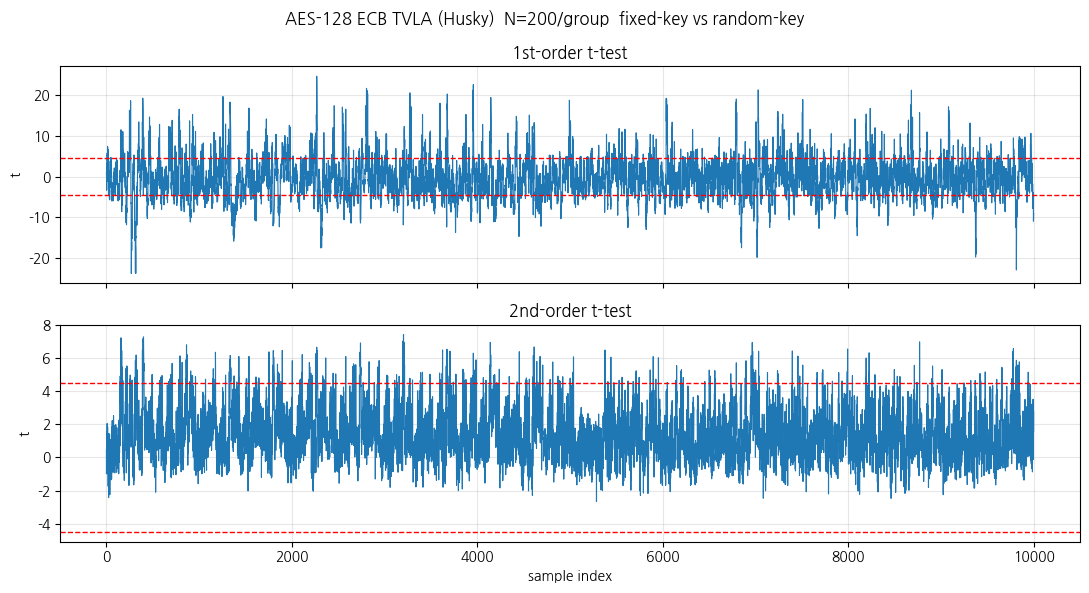

|t| > 4.5 샘플 수: 1차 3045/10000, 2차 458/10000
해석: 비보호 AES에서는 1차 봉우리가 임계를 넘는 것이 흔하다. 정렬·잡음·게인에 따라 위치와 크기는 달라진다. t-test 단독으로 안전/불안전을 단정하지 않는다.


In [9]:
def traces_to_int16(traces_f, peak=None):
    # float (n, ns) → int16 (n, ns)
    # peak가 None이면 |traces| 전역 최댓값을 쓴다.
    tr = np.asarray(traces_f, dtype=np.float64)
    if tr.ndim != 2:
        raise ValueError("traces는 2D여야 한다. shape=%s" % (tr.shape,))
    if peak is None:
        peak = float(np.max(np.abs(tr)))
    if peak <= 0:
        peak = 1.0
    scale = 30000.0 / peak
    out = np.clip(np.rint(tr * scale), -32768, 32767).astype(np.int16)
    return out, scale, peak


peak_all = float(max(np.max(np.abs(traces_rk)), np.max(np.abs(traces_fk))))
tr_rk_i16, scale, peak_all = traces_to_int16(traces_rk, peak=peak_all)
tr_fk_i16, _, _ = traces_to_int16(traces_fk, peak=peak_all)
print("int16 변환: peak=%.6g, scale=%.6g" % (peak_all, scale))
print("tr_rk_i16", tr_rk_i16.shape, tr_rk_i16.dtype)

labels_rk = np.zeros((N_TRACES,), dtype=np.uint16)
labels_fk = np.ones((N_TRACES,), dtype=np.uint16)

ttest = Ttest(d=2)
ttest.fit_u(tr_rk_i16, labels_rk)
ttest.fit_u(tr_fk_i16, labels_fk)
tt = ttest.get_ttest()
print("get_ttest() shape:", tt.shape)

for order in range(tt.shape[0]):
    abs_t = np.abs(tt[order])
    j = int(np.nanargmax(abs_t))
    print("  %d차 max |t| = %.2f  @ sample %d" % (order + 1, abs_t[j], j))

ns = tt.shape[1]
x_axis = np.arange(ns)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
titles = ["1st-order t-test", "2nd-order t-test"]
for ax, order, title in zip(axes, (0, 1), titles):
    ax.plot(x_axis, tt[order], lw=0.8, color="C0")
    ax.axhline(THRESHOLD, color="r", ls="--", lw=1)
    ax.axhline(-THRESHOLD, color="r", ls="--", lw=1)
    ax.set_ylabel("t")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("sample index")
fig.suptitle(
    "AES-128 ECB TVLA (Husky)  N=%d/group  fixed-key vs random-key" % N_TRACES,
    fontsize=12,
)
fig.tight_layout()
plt.show()

print(
    "|t| > %.1f 샘플 수: 1차 %d/%d, 2차 %d/%d"
    % (
        THRESHOLD,
        int(np.sum(np.abs(tt[0]) > THRESHOLD)),
        ns,
        int(np.sum(np.abs(tt[1]) > THRESHOLD)),
        ns,
    )
)
print(
    "해석: 비보호 AES에서는 1차 봉우리가 임계를 넘는 것이 흔하다. "
    "정렬·잡음·게인에 따라 위치와 크기는 달라진다. "
    "t-test 단독으로 안전/불안전을 단정하지 않는다."
)


---
## 9. 자원 해제

수집·분석이 끝나면 타겟과 스코프를 닫아 USB·시리얼을 반환한다.


In [10]:
def disconnect_all(scopes_dict, target_obj):
    try:
        target_obj.dis()
        print("[OK] target.dis()")
    except Exception as e:
        print("[WARN] target.dis():", e)
    for name, sc in list(scopes_dict.items()):
        try:
            sc.dis()
            print("[OK] %s.dis()" % name)
        except Exception as e:
            print("[WARN] %s.dis(): %s" % (name, e))
    scopes_dict.clear()


disconnect_all(scopes, target)
print("완료.")


[OK] target.dis()
[OK] ChipWhisperer_Husky.dis()
[OK] ChipWhisperer_Lite.dis()
완료.


---
## 10. 요약

| 항목 | 내용 |
|------|------|
| 타겟 암호 | tiny-AES-c AES-128 **ECB**, 블록 16바이트 |
| 펌웨어 경로 | `simpleserial_main/` + `../tiny-AES-c/aes.c` |
| 통신 | Lite + SimpleSerial2 (`0x81` / `0x82` / `0x83`) |
| 측정 | Husky 와이어태핑 (D0 트리거, AUX 클럭, Measure 션트) |
| TVLA 집단 | random-key vs fixed-key, **고정 평문** |
| SCALib | `traces` int16 `(n,ns)`, 라벨 uint16 ∈ {0,1}, `Ttest(d)` → `fit_u` → `get_ttest` |
| 임계 | \|t\|=4.5 관례 경보선. 진단용이며 최종 보안 판정이 아니다 |

### 실패 시 점검

1. `list_devices`에 Lite·Husky가 모두 보이는가.
2. 골든 AES가 일치하는가 (플래시·len=16).
3. Husky PLL lock / capture 타임아웃 (AUX·TRIG 배선).
4. 파형이 포화(클리핑)이면 `gain.db`를 낮춘다.
5. SCALib는 **pip `scalib`** 만 사용한다.

시뮬 API만 먼저 익히려면 `SCALib_TVLA_tutorial.ipynb`를 실행한다.
